In [ ]:
import numpy as np
import matplotlib.pyplot as plt


from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

In [ ]:
diabetes = load_diabetes()

X = diabetes.data
y = diabetes.target

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
def create_model(learning_rate):
    model = Sequential([
        Dense(64, activation='relu', input_shape=(X_train.shape[1],)), Dense(32, activation='relu'), Dense(32, activation='relu'), Dense(16, activation='relu'), Dense(1, activation='linear')
    ])

    optimizer = Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss='mse',
        metrics=['mae']
    )

    return model



EFFECT OF LEARNING RATE

Training with Learning Rate = 0.1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
MSE : 3523.7596844062105
MAE : 46.81018957931004
R2  : 0.3349077467641791


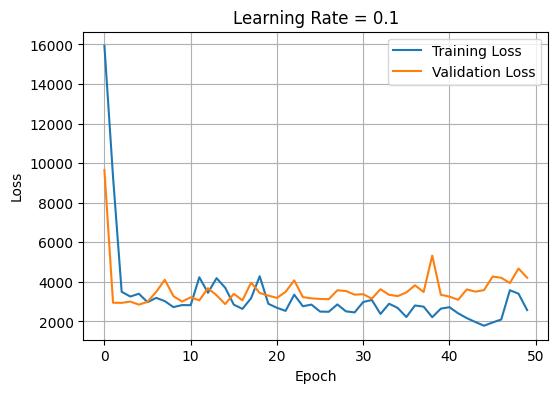


Training with Learning Rate = 0.01


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
MSE : 3337.835287426079
MAE : 45.92222650935141
R2  : 0.3700000592922579


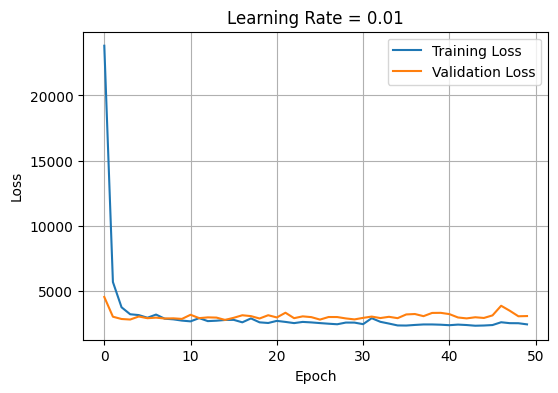


Training with Learning Rate = 0.001


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
MSE : 2861.9152718610967
MAE : 42.802015626028684
R2  : 0.4598276139103815


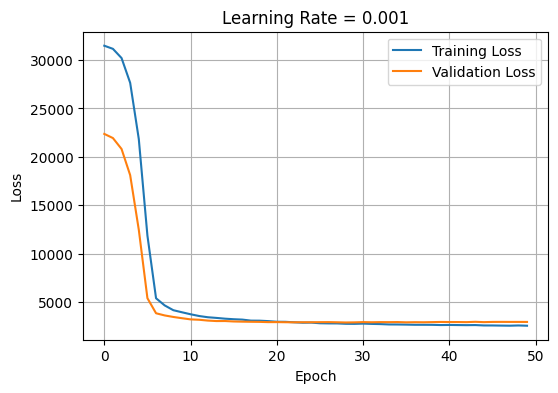


Training with Learning Rate = 0.0001


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
MSE : 5429.613939390256
MAE : 56.96723385071486
R2  : -0.024812839856929836


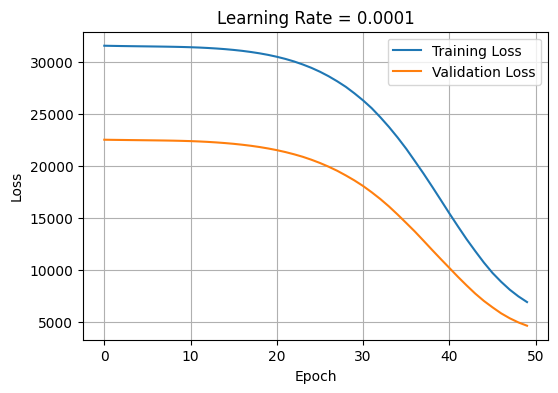

In [ ]:
learning_rates = [0.1, 0.01, 0.001, 0.0001]

print("EFFECT OF LEARNING RATE")

for lr in learning_rates:

    print(f"\nTraining with Learning Rate = {lr}")

    model = create_model(lr)

    history = model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=50,
        batch_size=16,
        verbose=0
    )

    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print("MSE :", mse)
    print("MAE :", mae)
    print("R2  :", r2)

    plt.figure(figsize=(6,4))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'Learning Rate = {lr}')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

EFFECT OF EPOCHS


Training with Epochs = 10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
MSE : 3765.9652030552525
MAE : 48.1422594906239
R2  : 0.2891926502275698


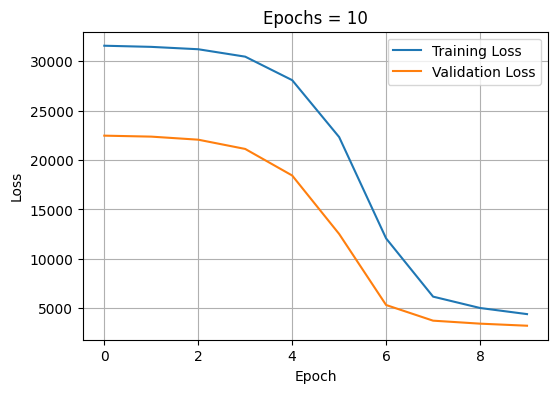


Training with Epochs = 30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
MSE : 2920.267345217451
MAE : 42.61165241712934
R2  : 0.44881394798948904


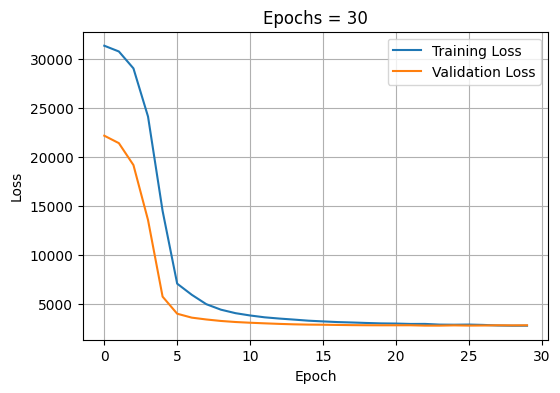


Training with Epochs = 50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
MSE : 2807.8392609577804
MAE : 42.060685704263406
R2  : 0.4700341941425269


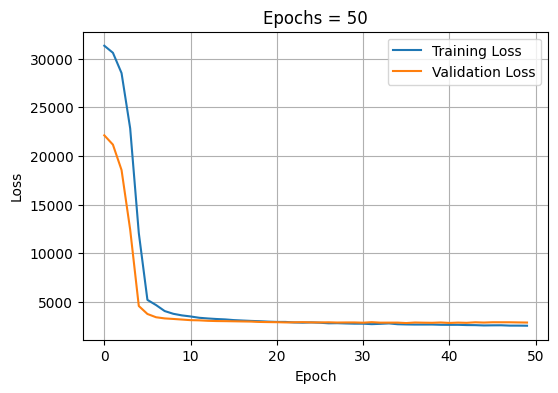


Training with Epochs = 100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
MSE : 2882.345981080673
MAE : 41.75582761443063
R2  : 0.45597141835590416


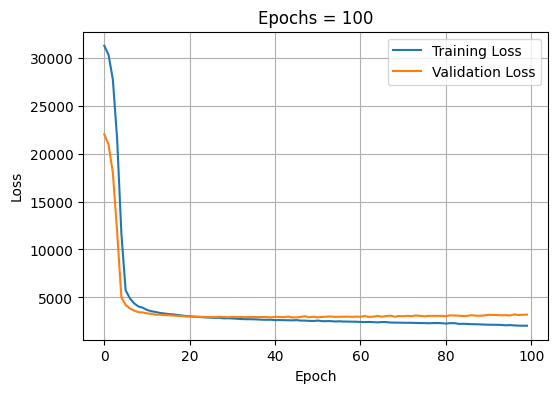

In [ ]:
epochs_list = [10, 30, 50, 100]

print("EFFECT OF EPOCHS\n")

for epochs in epochs_list:

    print(f"\nTraining with Epochs = {epochs}")

    model = create_model(0.001)

    history = model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=epochs,
        batch_size=16,
        verbose=0
    )

    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print("MSE :", mse)
    print("MAE :", mae)
    print("R2  :", r2)

    plt.figure(figsize=(6,4))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'Epochs = {epochs}')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

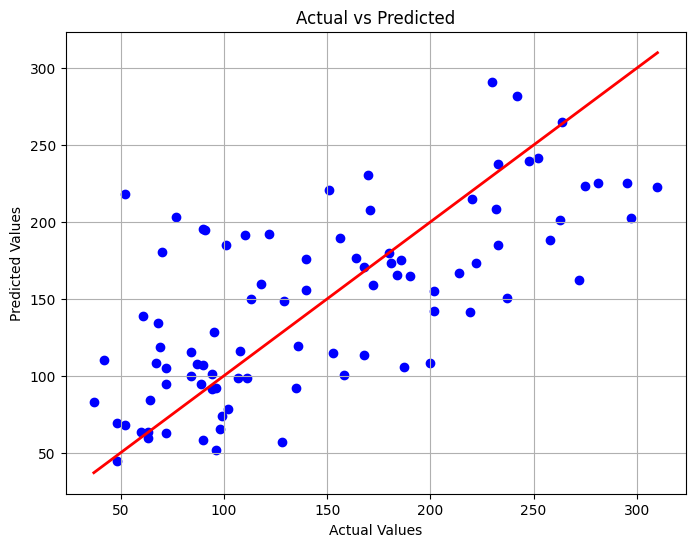

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, color='blue')
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2
)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.grid(True)
plt.show()